# ADC Single Sample Technical Report

## Methods

A DC voltage sweep from 0 V to 3 V in 0.5 V increments was applied to AIN0 using a power supply. For each voltage level, three independent measurements were collected using an oscilloscope, resulting in 21 total datasets. The oscilloscope data were exported as CSV files and analyzed in Python.

Waveform data were processed by extracting time and voltage columns and identifying LED pulse behavior using threshold-based edge detection. The high (baseline) voltage was estimated from the upper percentile of the signal, and the pulse low level was determined from the most frequent intermediate voltage values, excluding the large terminal drop in the waveform. A threshold between these levels was used to detect transitions into and out of the pulse state. A pulse was defined as a complete falling–rising edge pair, and only pulses with durations below a fixed threshold were retained to exclude the large end-of-window drop.

For each dataset, pulse start and end times were used to compute frequency, duty cycle, and active duration. Frequency was calculated from the number of completed pulse intervals over the detected active window. Duty cycle was computed as the ratio of average pulse width to average period, and active duration was defined as the time between the first and last detected pulses.

For each input voltage, mean values and 95% confidence intervals were calculated across the three replicates. A linear regression was performed on frequency versus input voltage to quantify linearity, reporting slope, intercept, coefficient of determination (R²), and statistical significance. Representative waveform segments corresponding to the 5 s active window were also plotted for each voltage level.

## Results

### Linear Regression and Analysis of Duty Cycle and Ontime Duration


Linear regression: frequency vs input voltage
Slope = 1.3290 ± 0.0040 Hz/V (95% CI)
Intercept = 0.9908 ± 0.0072 Hz (95% CI)
R^2 = 1.0000
p-value = 2.1737e-43


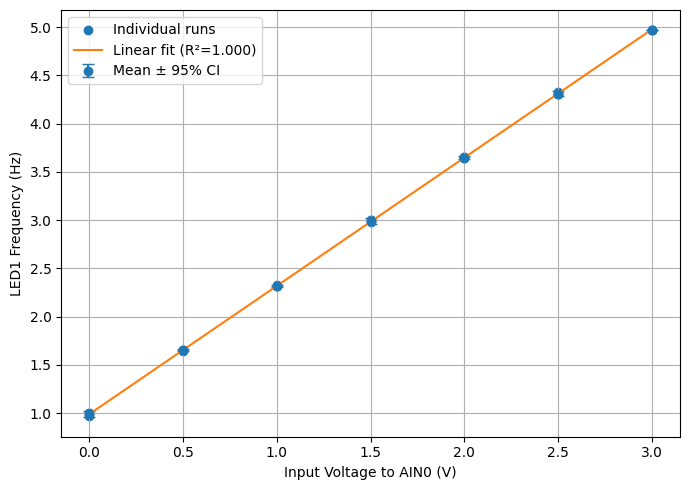

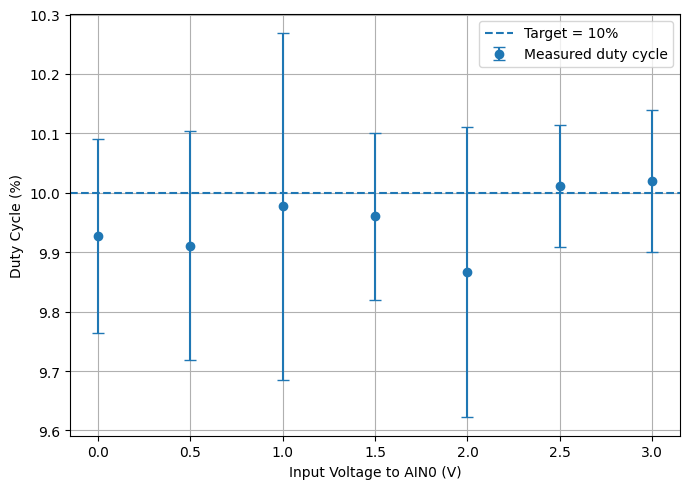

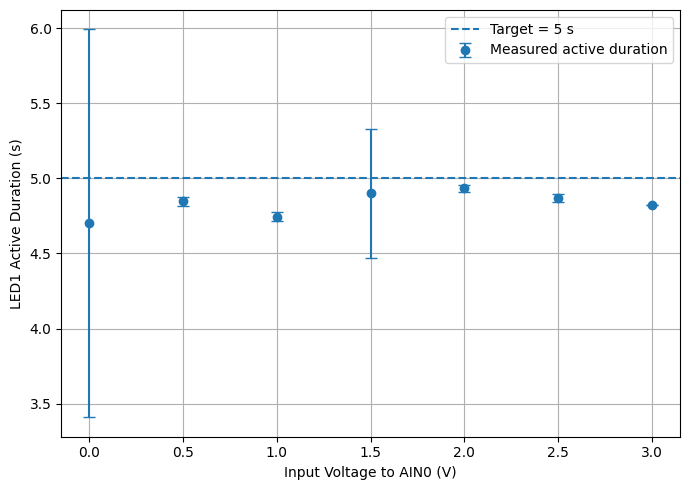

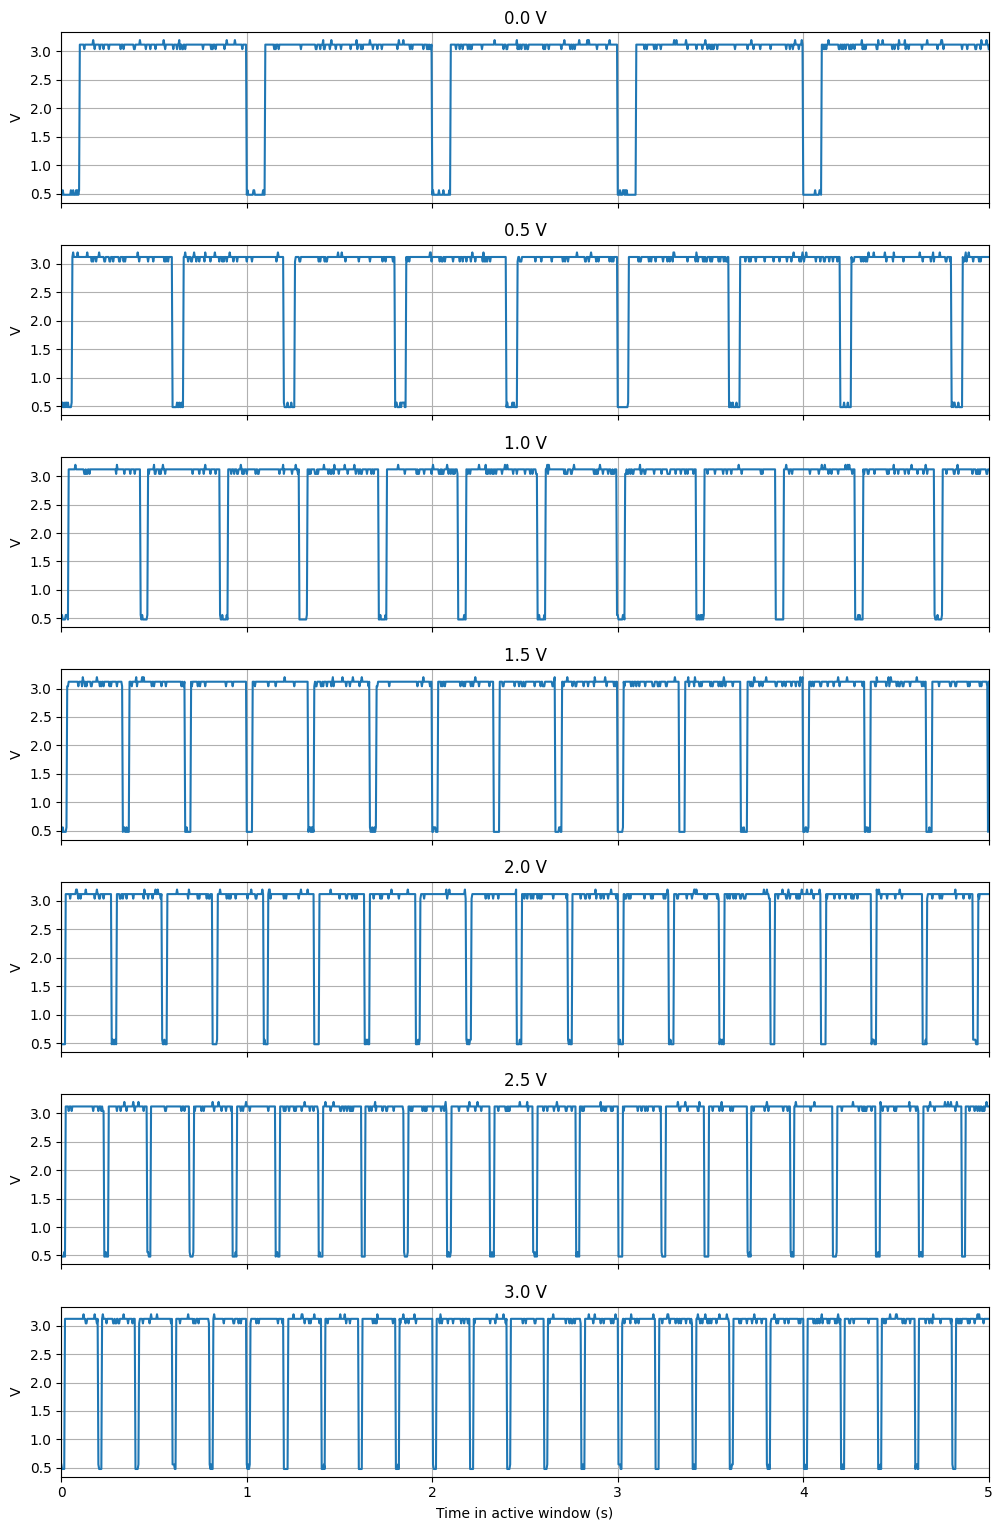


95% CI summary table:
 Input Voltage (V)  Freq Mean (Hz) Freq CI (Hz)  Duty Mean (%)   Duty CI (%)  On-Time Mean (s) On-Time CI (s)
               0.0        0.991870 [0.96, 1.03]       9.927410 [9.76, 10.09]          4.700000   [3.41, 5.99]
               0.5        1.650172 [1.64, 1.66]       9.910818 [9.72, 10.10]          4.848000   [4.82, 4.88]
               1.0        2.318076 [2.30, 2.33]       9.977237 [9.69, 10.27]          4.745333   [4.72, 4.77]
               1.5        2.992908 [2.96, 3.02]       9.960531 [9.82, 10.10]          4.900000   [4.47, 5.33]
               2.0        3.648657 [3.63, 3.67]       9.866923 [9.62, 10.11]          4.933333   [4.91, 4.96]
               2.5        4.312722 [4.29, 4.34]      10.011010 [9.91, 10.11]          4.869333   [4.84, 4.90]
               3.0        4.975124 [4.98, 4.98]      10.019428 [9.90, 10.14]          4.824000   [4.82, 4.82]


In [30]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

DATA_DIR = Path("exp1_data")
CSV_FILES = sorted(list(DATA_DIR.glob("TEK*.CSV")) + list(DATA_DIR.glob("TEK*.csv")))

TARGET_DUTY = 10.0
TARGET_ACTIVE_TIME = 5.0

FILE_TO_VOLTAGE = {
    0: 3.0, 1: 3.0, 2: 3.0,
    3: 2.5, 4: 2.5, 5: 2.5,
    6: 2.0, 7: 2.0, 8: 2.0,
    9: 1.5, 10: 1.5, 11: 1.5,
    18: 0.0, 19: 0.0, 20: 0.0,
    21: 1.0, 22: 1.0, 23: 1.0,
    24: 0.5, 25: 0.5, 26: 0.5,
}
BAD_FILES = set(range(12, 18))

def extract_file_number(path):
    m = re.search(r"TEK0*(\d+)\.csv$", path.name, re.IGNORECASE)
    return int(m.group(1)) if m else None

def load_scope_csv(path):
    df = pd.read_csv(path, header=None)
    t = pd.to_numeric(df.iloc[:, 3], errors="coerce")
    v = pd.to_numeric(df.iloc[:, 4], errors="coerce")
    valid = t.notna() & v.notna()
    t = t[valid].to_numpy(dtype=float)
    v = v[valid].to_numpy(dtype=float)
    t = t - t[0]
    return t, v

def measure_waveform_metrics(t, v, max_pulse_width_s=0.12):
    """
    Detect active-low LED pulses from quantized scope data.

    A pulse is counted only when:
    1) the signal crosses below the pulse threshold
    2) the signal crosses back above the threshold

    Long low intervals (the large end drop) are rejected by width.
    """
    t = np.asarray(t, dtype=float)
    v = np.asarray(v, dtype=float)

    if len(t) < 3:
        return {
            "baseline_v": np.nan,
            "pulse_low_v": np.nan,
            "threshold_v": np.nan,
            "first_edge_time_s": np.nan,
            "last_edge_time_s": np.nan,
            "frequency_hz": np.nan,
            "period_s": np.nan,
            "duty_cycle_pct": np.nan,
            "active_time_s": np.nan,
            "n_pulses": 0,
        }

    baseline = np.percentile(v, 95)

    vq = np.round(v, 2)
    unique_vals, counts = np.unique(vq, return_counts=True)

    candidates = [
        (val, count)
        for val, count in zip(unique_vals, counts)
        if (-1.0 < val < baseline - 0.2)
    ]

    if not candidates:
        return {
            "baseline_v": baseline,
            "pulse_low_v": np.nan,
            "threshold_v": np.nan,
            "first_edge_time_s": np.nan,
            "last_edge_time_s": np.nan,
            "frequency_hz": np.nan,
            "period_s": np.nan,
            "duty_cycle_pct": np.nan,
            "active_time_s": np.nan,
            "n_pulses": 0,
        }

    pulse_low = sorted(candidates, key=lambda x: x[1], reverse=True)[0][0]
    threshold = 0.5 * (baseline + pulse_low)

    is_low = v < threshold
    edges = np.diff(is_low.astype(int))

    falling_edges = np.where(edges == 1)[0] + 1
    rising_edges = np.where(edges == -1)[0] + 1

    if len(rising_edges) and len(falling_edges) and rising_edges[0] < falling_edges[0]:
        rising_edges = rising_edges[1:]

    n_pairs = min(len(falling_edges), len(rising_edges))
    falling_edges = falling_edges[:n_pairs]
    rising_edges = rising_edges[:n_pairs]

    valid = rising_edges > falling_edges
    falling_edges = falling_edges[valid]
    rising_edges = rising_edges[valid]

    if len(falling_edges) == 0:
        return {
            "baseline_v": baseline,
            "pulse_low_v": pulse_low,
            "threshold_v": threshold,
            "first_edge_time_s": np.nan,
            "last_edge_time_s": np.nan,
            "frequency_hz": np.nan,
            "period_s": np.nan,
            "duty_cycle_pct": np.nan,
            "active_time_s": np.nan,
            "n_pulses": 0,
        }

    pulse_starts = t[falling_edges]
    pulse_ends = t[rising_edges]
    pulse_widths = pulse_ends - pulse_starts

    short_mask = pulse_widths <= max_pulse_width_s
    pulse_starts = pulse_starts[short_mask]
    pulse_ends = pulse_ends[short_mask]
    pulse_widths = pulse_widths[short_mask]

    if len(pulse_starts) < 2:
        return {
            "baseline_v": baseline,
            "pulse_low_v": pulse_low,
            "threshold_v": threshold,
            "first_edge_time_s": pulse_starts[0] if len(pulse_starts) else np.nan,
            "last_edge_time_s": pulse_ends[-1] if len(pulse_ends) else np.nan,
            "frequency_hz": np.nan,
            "period_s": np.nan,
            "duty_cycle_pct": np.nan,
            "active_time_s": np.nan,
            "n_pulses": len(pulse_starts),
        }

    periods = np.diff(pulse_starts)
    periods = periods[periods > 0]

    if len(periods) == 0:
        return {
            "baseline_v": baseline,
            "pulse_low_v": pulse_low,
            "threshold_v": threshold,
            "first_edge_time_s": pulse_starts[0],
            "last_edge_time_s": pulse_ends[-1],
            "frequency_hz": np.nan,
            "period_s": np.nan,
            "duty_cycle_pct": np.nan,
            "active_time_s": np.nan,
            "n_pulses": len(pulse_starts),
        }

    mean_period = np.mean(periods)
    active_time = pulse_ends[-1] - pulse_starts[0]
    freq = (len(pulse_starts) - 1) / active_time if active_time > 0 else np.nan

    usable_widths = pulse_widths[:len(periods)]
    duty = 100.0 * np.mean(usable_widths) / mean_period

    return {
        "baseline_v": baseline,
        "pulse_low_v": pulse_low,
        "threshold_v": threshold,
        "first_edge_time_s": pulse_starts[0],
        "last_edge_time_s": pulse_ends[-1],
        "frequency_hz": freq,
        "period_s": mean_period,
        "duty_cycle_pct": duty,
        "active_time_s": active_time,
        "n_pulses": len(pulse_starts),
    }

def mean_ci(x, confidence=0.95):
    x = pd.Series(x).dropna().to_numpy(dtype=float)
    n = len(x)
    if n == 0:
        return np.nan, np.nan, np.nan, np.nan
    mean = np.mean(x)
    sd = np.std(x, ddof=1) if n > 1 else 0.0
    sem = sd / np.sqrt(n) if n > 1 else 0.0
    ci = stats.t.ppf((1 + confidence) / 2, df=n - 1) * sem if n > 1 else 0.0
    return mean, sd, sem, ci

rows = []

for f in CSV_FILES:
    num = extract_file_number(f)
    if num is None or num in BAD_FILES or num not in FILE_TO_VOLTAGE:
        continue

    vin = FILE_TO_VOLTAGE[num]
    t, v = load_scope_csv(f)
    m = measure_waveform_metrics(t, v)

    rows.append({
        "file": f.name,
        "file_num": num,
        "input_voltage_v": vin,
        "baseline_v": m["baseline_v"],
        "pulse_low_v": m["pulse_low_v"],
        "threshold_v": m["threshold_v"],
        "first_edge_time_s": m["first_edge_time_s"],
        "last_edge_time_s": m["last_edge_time_s"],
        "frequency_hz": m["frequency_hz"],
        "period_s": m["period_s"],
        "duty_cycle_pct": m["duty_cycle_pct"],
        "active_time_s": m["active_time_s"],
        "n_pulses": m["n_pulses"],
    })

results_df = pd.DataFrame(rows)

if results_df.empty:
    raise ValueError("No valid files found after parsing.")

results_df = results_df.sort_values(["input_voltage_v", "file_num"], ascending=[True, True])
results_df["sweep_direction"] = "decreasing"

summary_rows = []
for vin, grp in results_df.groupby("input_voltage_v", sort=True):
    f_mean, f_sd, f_sem, f_ci = mean_ci(grp["frequency_hz"])
    d_mean, d_sd, d_sem, d_ci = mean_ci(grp["duty_cycle_pct"])
    a_mean, a_sd, a_sem, a_ci = mean_ci(grp["active_time_s"])

    summary_rows.append({
        "input_voltage_v": vin,
        "n": len(grp),

        "freq_mean_hz": f_mean,
        "freq_sd_hz": f_sd,
        "freq_95ci_hz": f_ci,

        "duty_mean_pct": d_mean,
        "duty_sd_pct": d_sd,
        "duty_95ci_pct": d_ci,

        "active_mean_s": a_mean,
        "active_sd_s": a_sd,
        "active_95ci_s": a_ci,

        "duty_abs_error_pct_points": d_mean - TARGET_DUTY,
        "duty_percent_error": 100 * (d_mean - TARGET_DUTY) / TARGET_DUTY,

        "active_abs_error_s": a_mean - TARGET_ACTIVE_TIME,
        "active_percent_error": 100 * (a_mean - TARGET_ACTIVE_TIME) / TARGET_ACTIVE_TIME,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("input_voltage_v")

x = results_df["input_voltage_v"].to_numpy(dtype=float)
y = results_df["frequency_hz"].to_numpy(dtype=float)

mask = np.isfinite(x) & np.isfinite(y)
x = x[mask]
y = y[mask]

regression_ok = len(x) >= 2 and len(np.unique(x)) >= 2

if regression_ok:
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value**2

    n = len(x)
    x_mean = np.mean(x)
    ssx = np.sum((x - x_mean)**2)
    y_hat = intercept + slope * x
    residuals = y - y_hat
    s_err = np.sqrt(np.sum(residuals**2) / (n - 2))
    tcrit = stats.t.ppf(0.975, df=n - 2)

    slope_ci = tcrit * s_err / np.sqrt(ssx)
    intercept_ci = tcrit * s_err * np.sqrt(1/n + x_mean**2 / ssx)

    print("\nLinear regression: frequency vs input voltage")
    print(f"Slope = {slope:.4f} ± {slope_ci:.4f} Hz/V (95% CI)")
    print(f"Intercept = {intercept:.4f} ± {intercept_ci:.4f} Hz (95% CI)")
    print(f"R^2 = {r_squared:.4f}")
    print(f"p-value = {p_value:.4e}")
else:
    print("\nNot enough valid data points to run linear regression.")

plt.figure(figsize=(7, 5))
plt.scatter(results_df["input_voltage_v"], results_df["frequency_hz"], label="Individual runs")
plt.errorbar(
    summary_df["input_voltage_v"],
    summary_df["freq_mean_hz"],
    yerr=summary_df["freq_95ci_hz"],
    fmt="o",
    capsize=4,
    label="Mean ± 95% CI"
)

if regression_ok:
    xfit = np.linspace(summary_df["input_voltage_v"].min(), summary_df["input_voltage_v"].max(), 200)
    yfit = intercept + slope * xfit
    plt.plot(xfit, yfit, label=f"Linear fit (R²={r_squared:.3f})")

plt.xlabel("Input Voltage to AIN0 (V)")
plt.ylabel("LED1 Frequency (Hz)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.errorbar(
    summary_df["input_voltage_v"],
    summary_df["duty_mean_pct"],
    yerr=summary_df["duty_95ci_pct"],
    fmt="o",
    capsize=4,
    linestyle="none",
    label="Measured duty cycle"
)
plt.axhline(TARGET_DUTY, linestyle="--", label="Target = 10%")
plt.xlabel("Input Voltage to AIN0 (V)")
plt.ylabel("Duty Cycle (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.errorbar(
    summary_df["input_voltage_v"],
    summary_df["active_mean_s"],
    yerr=summary_df["active_95ci_s"],
    fmt="o",
    capsize=4,
    linestyle="none",
    label="Measured active duration"
)
plt.axhline(TARGET_ACTIVE_TIME, linestyle="--", label="Target = 5 s")
plt.xlabel("Input Voltage to AIN0 (V)")
plt.ylabel("LED1 Active Duration (s)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

voltages_for_waveforms = sorted(summary_df["input_voltage_v"].unique())
rep_files = []

for vin in voltages_for_waveforms:
    grp = results_df[results_df["input_voltage_v"] == vin].sort_values("file_num")
    if not grp.empty:
        rep_files.append((vin, grp.iloc[0]["file"]))

fig, axes = plt.subplots(len(rep_files), 1, figsize=(10, 2.2 * len(rep_files)), sharex=True)

if len(rep_files) == 1:
    axes = [axes]

for ax, (vin, fname) in zip(axes, rep_files):
    fpath = DATA_DIR / fname
    t, v = load_scope_csv(fpath)
    m = measure_waveform_metrics(t, v)

    if np.isfinite(m["first_edge_time_s"]) and np.isfinite(m["last_edge_time_s"]):
        mask = (t >= m["first_edge_time_s"]) & (t <= m["first_edge_time_s"] + 5.0)
        t_plot = t[mask] - m["first_edge_time_s"]
        v_plot = v[mask]
    else:
        t_plot = t
        v_plot = v

    ax.plot(t_plot, v_plot)
    ax.set_xlim(0, 5)
    ax.set_ylabel("V")
    ax.set_title(f"{vin:.1f} V")
    ax.grid(True)

axes[-1].set_xlabel("Time in active window (s)")
plt.tight_layout()
plt.show()

ci_table = []

for _, row in summary_df.iterrows():
    ci_table.append({
        "Input Voltage (V)": row["input_voltage_v"],

        "Freq Mean (Hz)": row["freq_mean_hz"],
        "Freq CI (Hz)": f"[{row['freq_mean_hz'] - row['freq_95ci_hz']:.2f}, {row['freq_mean_hz'] + row['freq_95ci_hz']:.2f}]",

        "Duty Mean (%)": row["duty_mean_pct"],
        "Duty CI (%)": f"[{row['duty_mean_pct'] - row['duty_95ci_pct']:.2f}, {row['duty_mean_pct'] + row['duty_95ci_pct']:.2f}]",

        "On-Time Mean (s)": row["active_mean_s"],
        "On-Time CI (s)": f"[{row['active_mean_s'] - row['active_95ci_s']:.2f}, {row['active_mean_s'] + row['active_95ci_s']:.2f}]",
    })

ci_df = pd.DataFrame(ci_table).sort_values("Input Voltage (V)")

print("\n95% CI summary table:")
print(ci_df.to_string(index=False))

## Discussion

The relationship between input voltage and LED blinking frequency was highly linear, with a slope of 1.3290 ± 0.0040 Hz/V and an intercept of 0.9908 ± 0.0072 Hz. The near-perfect R² value (1.0000) indicates a strong linear mapping between AIN0 voltage and output frequency, showing that the system reliably converts analog input into timing behavior with minimal noise or nonlinearity. Small deviations from exact integer frequencies (e.g., ~0.99 Hz instead of 1 Hz) are likely due to timer resolution limits in the embedded system. Hysteresis was not explicitly evaluated because the firmware implements a single-sample, memoryless mapping from input voltage to output frequency, so sweep direction is not expected to influence the result beyond measurement noise.

Measured duty cycles were consistently close to the 10% target across all voltages, with confidence intervals overlapping the expected value. This indicates that the timer-based control logic generating the LED signal maintains a stable duty cycle independent of frequency. Minor deviations are likely due to quantization in timer counts and edge detection limitations.

The measured active duration was slightly below the expected 5 s (typically ~4.7-4.9 s), which is expected since duration was calculated using detected pulse edges rather than exact timer boundaries. Variability was higher at lower voltages due to fewer pulses, making the measurement more sensitive to timing differences.

Representative waveform plots confirm that frequency increases monotonically with input voltage while pulse width remains consistent, supporting both the observed linearity and duty cycle stability. Overall, the system demonstrates strong linearity, high precision, and stable timing behavior, with small errors primarily due to timer discretization and measurement methodology.